In [98]:
# ! pip install yfinance
import Ab as ab
import datetime as dt
import matplotlib.pyplot as plt
import pandas as pd

# Get data from yahoo finance
sd = dt.datetime(2015,1,1)
ed = dt.datetime(2025,1,1)
# 1x leveraged nasdaq 100 etf
qqq = ab.StockData('QQQ')
qqq.get_data_from_yfinance('QQQ', sd, ed)
# 2x leveraged nasdaq 100 etf
qld = ab.StockData('QLD')
qld.get_data_from_yfinance('QLD', sd, ed)
# 3x leveraged nasdaq 100 etf
tqqq = ab.StockData('TQQQ')
tqqq.get_data_from_yfinance('TQQQ', sd, ed)
#nasdaq 100 index
ndx = ab.StockData('NDX')
ndx.get_data_from_yfinance('NDX', sd, ed)
#S&P 500 etf
spy = ab.StockData('SPY')
spy.get_data_from_yfinance('SPY', sd, ed)
#nasdaq stocks above 200 day moving average percentage
naa200r = ab.StockData('NAA200R')
naa200r.get_data_from_csv('data/NAA200R.csv')

ffty = ab.StockData('FFTY')
ffty.get_data_from_yfinance('FFTY',sd,ed+dt.timedelta(days=1))




[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [99]:
test_start = dt.datetime(2015,1,1)
test_end = dt.datetime(2025,1,1)
ticker = qld
weekly_buy = weekly_sell = True
long_term_tax_rate = short_term_tax_rate = 0

threshold_strategy = ab.Threshold(name='NAA200R', buy_threshold = 15, sell_threshold = 30, signal_ma_window=20)
threshold_strategy.run_strategy(naa200r, test_start , test_end)
naa200r_threshold_bt = ab.BackTest()
naa200r_threshold_bt.run_backtest(threshold_strategy, ticker, test_start , test_end, )
naa200r_threshold_bt.performance_summary()


NAA200R 15/30 MA 20:
cumulative return      : 1457.55%
compound anual return  : 31.5965%
max_drawdown           : -43.97%
sharp_ratio            : 6.06%
average of daily return: 0.1337%
std of daily return    : 2.2053%
number of trades       : 24,
trading days           : 3651,
batting Average        : 43.48%
Gain Average           : 59.48%
Loss Average           : -7.21%
Risk Reward Ratio      : 8.25
Gain STD               : 83.60%
Loss STD               : 3.49%
            


In [100]:
long_term_tax_rate, short_term_tax_rate = 0.2, 0.5

naa200r_threshold_bt_tax = ab.BackTest()
naa200r_threshold_bt_tax.run_backtest(threshold_strategy, ticker, test_start , test_end,
                                  long_term_tax_rate = long_term_tax_rate,
                                  short_term_tax_rate = short_term_tax_rate, verbose =False)
naa200r_threshold_bt_tax.performance_summary()


NAA200R 15/30 MA 20:
cumulative return      : 805.02%
compound anual return  : 24.6425%
max_drawdown           : -53.22%
sharp_ratio            : 5.03%
average of daily return: 0.1133%
std of daily return    : 2.2529%
number of trades       : 30,
trading days           : 3651,
batting Average        : 43.48%
Gain Average           : 59.48%
Loss Average           : -7.21%
Risk Reward Ratio      : 8.25
Gain STD               : 83.60%
Loss STD               : 3.49%
            


In [101]:
long_term_tax_rate, short_term_tax_rate = 0, 0
buy_and_hold = ab.BuyAndHold()
buy_and_hold.run_strategy(ticker, test_start,test_end)
bt = ab.BackTest()
bt.run_backtest(buy_and_hold, ticker, test_start, test_end,
                                  long_term_tax_rate = long_term_tax_rate,
                                  short_term_tax_rate = short_term_tax_rate, )
bt.performance_summary()


Buy and Hold:
cumulative return      : 1190.29%
compound anual return  : 29.1424%
max_drawdown           : -63.08%
sharp_ratio            : 5.09%
average of daily return: 0.1398%
std of daily return    : 2.7485%
number of trades       : 2,
trading days           : 3651,
batting Average        : 100.00%
Gain Average           : 1190.29%
Loss Average           : nan%
Risk Reward Ratio      : 0.00
Gain STD               : nan%
Loss STD               : nan%
            


In [102]:
long_term_tax_rate, short_term_tax_rate = 0.2, 0.5
buy_and_hold = ab.BuyAndHold()
buy_and_hold.run_strategy(ticker, test_start,test_end)
bt = ab.BackTest()
bt.run_backtest(buy_and_hold, ticker, test_start, test_end,
                                  long_term_tax_rate = long_term_tax_rate,
                                  short_term_tax_rate = short_term_tax_rate, )
bt.performance_summary()


Buy and Hold:
cumulative return      : 952.23%
compound anual return  : 26.5351%
max_drawdown           : -63.08%
sharp_ratio            : 4.78%
average of daily return: 0.1326%
std of daily return    : 2.7770%
number of trades       : 2,
trading days           : 3651,
batting Average        : 100.00%
Gain Average           : 1190.29%
Loss Average           : nan%
Risk Reward Ratio      : 0.00
Gain STD               : nan%
Loss STD               : nan%
            


In [103]:
#buy and hold strategy vs various  strategies
def backtestAll(ticker:ab.StockData, indicator:ab.StockData, test_start:dt.datetime,test_end:dt.datetime, verbose = True, weekly_buy=False, weekly_sell=False):
    perf_summary = pd.DataFrame()
    buy_and_hold = ab.BuyAndHold()
    buy_and_hold.run_strategy(ticker, test_start,test_end)
    bt = ab.BackTest()
    bt.run_backtest(buy_and_hold, ticker, test_start, test_end)

    macross_strategy = ab.MACross('Ma Cross',50, 200)
    macross_strategy.run_strategy(indicator, test_start ,test_end)
    ma_cross_bt = ab.BackTest()
    ma_cross_bt.run_backtest(macross_strategy, ticker,test_start, test_end, weekly_buy,weekly_sell)

    threshold_strategy = ab.Threshold(name='NAA200R', buy_threshold = 15, sell_threshold = 30, signal_ma_window=20)
    threshold_strategy.run_strategy(naa200r, test_start , test_end)
    naa200r_threshold_bt = ab.BackTest()
    naa200r_threshold_bt.run_backtest(threshold_strategy, ticker, test_start , test_end, weekly_buy,weekly_sell)

    threshold_strategy_2 = ab.Threshold(name='NAA200R', buy_threshold = 15, sell_threshold = 30, signal_ma_window=40)
    threshold_strategy_2.run_strategy(naa200r, test_start , test_end)
    naa200r_threshold_bt_2 = ab.BackTest()
    naa200r_threshold_bt_2.run_backtest(threshold_strategy_2, ticker,test_start , test_end, weekly_buy,weekly_sell)

    ma_threshold = ab.MAThreshold('NAA200R SMA21', ma_window = 21,buy_threshold = 1, sell_threshold = 1)
    ma_threshold.run_strategy(indicator, test_start,test_end)
    ma_threshold_bt = ab.BackTest()
    ma_threshold_bt.run_backtest(ma_threshold, ticker,test_start, test_end, weekly_buy,weekly_sell)

    ma_threshold2 = ab.MAThreshold('SMA20', ma_window = 20)
    ma_threshold2.run_strategy(indicator, test_start,test_end)
    ma_threshold2_bt = ab.BackTest()
    ma_threshold2_bt.run_backtest(ma_threshold2, ticker,test_start, test_end, weekly_buy,weekly_sell)

    fftyspy_stg = ab.fftyspy_stg(ffty_sell_threshold = 0.95, ffty_buy_threshold = 1.02,
                                            spy_consecutive_buy_threshold = 1, spy_consecutive_days = 20,
                                            spy_max_off_new_high_pct = -0.2)
    fftyspy_stg.run_strategy([ffty,spy], test_start, test_end)
    fftyspy_bh = ab.BackTest()
    fftyspy_bh.run_backtest(fftyspy_stg,ticker,test_start,test_end)

    #WeeklyMAThreshold = ab.WeeklyMAThreshold('2W SMA200', ma_window =40,buy_threshold=1,sell_threshold=1)
    #WeeklyMAThreshold.run_strategy(indicator, test_start , test_end)
    #WeeklyMAThreshold_bt = ab.BackTest()
    #WeeklyMAThreshold_bt.run_backtest(WeeklyMAThreshold, ticker, test_start , test_end, weekly_buy,weekly_sell)

    print('Backtest for', ticker.ticker)
    bt.performance_summary()
    ma_cross_bt.performance_summary()
    naa200r_threshold_bt.performance_summary()
    naa200r_threshold_bt_2.performance_summary()
    ma_threshold_bt.performance_summary()
    ma_threshold2_bt.performance_summary()
    fftyspy_bh.performance_summary()
    #WeeklyMAThreshold_bt.performance_summary()

    fig = plt.figure(figsize=(16,4))
    plt.plot(bt.balance.index, bt.balance['Total'], label = bt.name ,color = 'blue')
    plt.plot(ma_cross_bt.balance.index, ma_cross_bt.balance['Total'], label = ma_cross_bt.name, color = 'red')
    plt.plot(naa200r_threshold_bt.balance.index, naa200r_threshold_bt.balance['Total'], label = naa200r_threshold_bt.name, color = 'green')
    plt.plot(naa200r_threshold_bt_2.balance.index, naa200r_threshold_bt_2.balance['Total'], label = naa200r_threshold_bt_2.name)
    plt.plot(ma_threshold_bt.balance.index, ma_threshold_bt.balance['Total'], label = ma_threshold_bt.name)
    plt.plot(ma_threshold2_bt.balance.index, ma_threshold2_bt.balance['Total'], label = ma_threshold2_bt.name)

    plt.plot(fftyspy_bh.balance.index, fftyspy_bh.balance['Total'], label = fftyspy_bh.name)
    #plt.plot(WeeklyMAThreshold_bt.balance.index, WeeklyMAThreshold_bt.balance['Total'], label = WeeklyMAThreshold_bt.name)

    plt.legend()
    plt.title('Backtesting for {}'.format(ticker.ticker))
    plt.show()


    for strategy in [bt,ma_cross_bt,naa200r_threshold_bt, naa200r_threshold_bt_2, ma_threshold_bt, ma_threshold2_bt]:
        perf_summary = pd.concat([perf_summary, strategy.summary_result])

    ma_threshold2_bt.trade_records.to_csv('ma_threshold2_bt.csv')
    return perf_summary


Backtest for QQQ

Buy and Hold:
cumulative return      : 436.64%
compound anual return  : 18.2955%
max_drawdown           : -35.12%
sharp_ratio            : 5.55%
average of daily return: 0.0763%
std of daily return    : 1.3745%
number of trades       : 2,
trading days           : 3651,
batting Average        : 100.00%
Gain Average           : 436.64%
Loss Average           : nan%
Risk Reward Ratio      : 0.00
Gain STD               : nan%
Loss STD               : nan%
            

Ma Cross 50/200:
cumulative return      : 336.13%
compound anual return  : 15.8676%
max_drawdown           : -28.56%
sharp_ratio            : 5.59%
average of daily return: 0.0655%
std of daily return    : 1.1717%
number of trades       : 7,
trading days           : 3651,
batting Average        : 66.67%
Gain Average           : 53.00%
Loss Average           : -8.59%
Risk Reward Ratio      : 6.17
Gain STD               : 25.76%
Loss STD               : 6.95%
            

NAA200R 15/30 MA 20:
cumulative retu

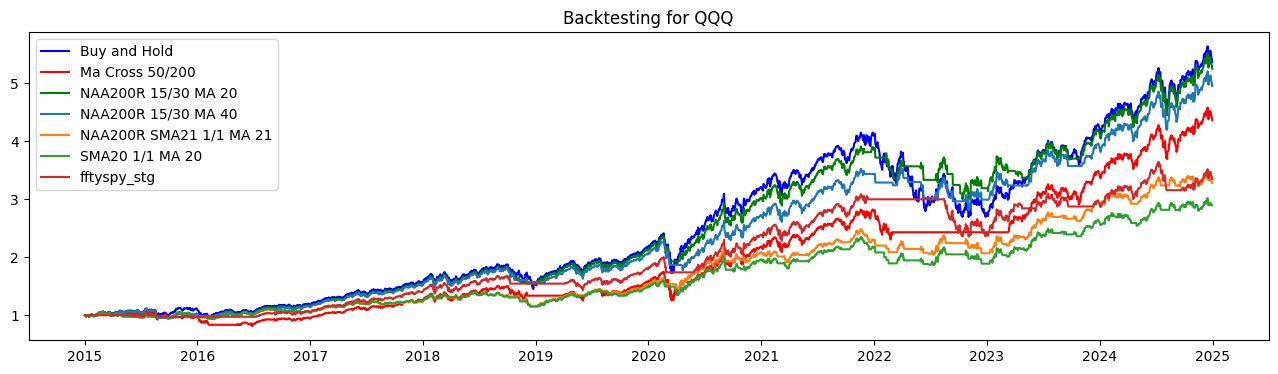

,name,num_trades,cumulative_return,annual_return,max_drawdown,sharp_ratio,avg_daily_return,std_daily_return,num_trading_days,batting Average,Gain Average,Loss Average,Risk Reward Ratio,Gain STD,Loss STD
0,Buy and Hold,2,4.366392,0.182955,-0.351187,0.055514,0.000763,0.013745,3651,1.000000,4.366392,NaN,0.000000,NaN,NaN
0,Ma Cross 50/200,7,3.361334,0.158676,-0.285594,0.055878,0.000655,0.011717,3651,0.666667,0.530010,-0.085882,6.171367,0.257566,0.069457
0,NAA200R 15/30 MA 20,24,4.252280,0.180415,-0.232338,0.065223,0.000721,0.011054,3651,0.434783,0.269270,-0.034941,7.706330,0.328815,0.016996
0,NAA200R 15/30 MA 40,23,3.953147,0.173514,-0.222638,0.065060,0.000693,0.010657,3651,0.545455,0.196072,-0.028204,6.951956,0.281538,0.022964
0,NAA200R SMA21 1/1 MA 21,119,2.285074,0.126301,-0.180616,0.060432,0.000508,0.008414,3651,0.415254,0.048103,-0.015365,3.130768,0.043608,0.011193
0,SMA20 1/1 MA 20,129,1.896002,0.112192,-0.208996,0.054095,0.000459,0.008484,3651,0.398438,0.045552,-0.015044,3.027918,0.040432,0.011640


In [104]:
perf_summary = backtestAll(qqq, qqq, test_start, test_end, verbose = False)
display(perf_summary)

Backtest for QLD

Buy and Hold:
cumulative return      : 1190.29%
compound anual return  : 29.1424%
max_drawdown           : -63.08%
sharp_ratio            : 5.09%
average of daily return: 0.1398%
std of daily return    : 2.7485%
number of trades       : 2,
trading days           : 3651,
batting Average        : 100.00%
Gain Average           : 1190.29%
Loss Average           : nan%
Risk Reward Ratio      : 0.00
Gain STD               : nan%
Loss STD               : nan%
            

Ma Cross 50/200:
cumulative return      : 938.52%
compound anual return  : 26.3693%
max_drawdown           : -51.72%
sharp_ratio            : 5.16%
average of daily return: 0.1208%
std of daily return    : 2.3405%
number of trades       : 7,
trading days           : 3651,
batting Average        : 66.67%
Gain Average           : 107.65%
Loss Average           : -18.10%
Risk Reward Ratio      : 5.95
Gain STD               : 63.97%
Loss STD               : 11.76%
            

NAA200R 15/30 MA 20:
cumulative

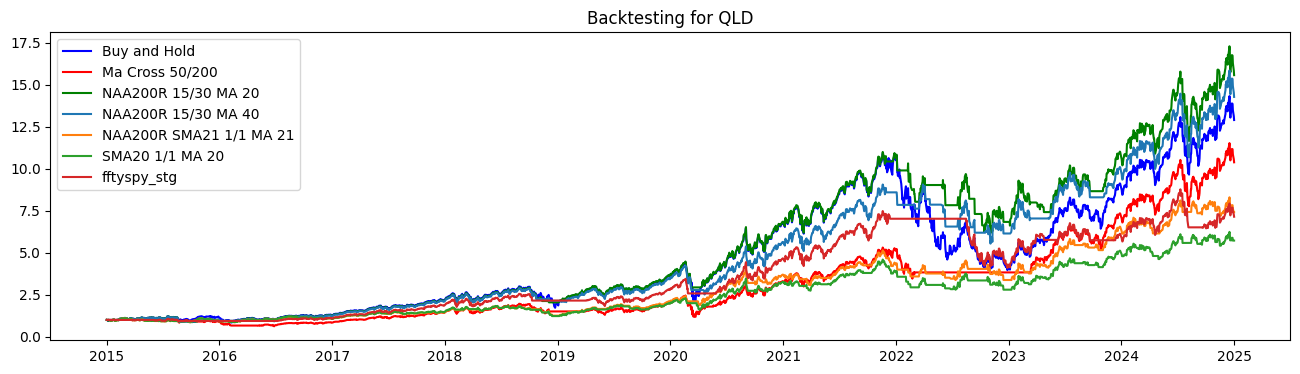

,name,num_trades,cumulative_return,annual_return,max_drawdown,sharp_ratio,avg_daily_return,std_daily_return,num_trading_days,batting Average,Gain Average,Loss Average,Risk Reward Ratio,Gain STD,Loss STD
0,Buy and Hold,2,11.902886,0.291424,-0.630810,0.050880,0.001398,0.027485,3651,1.000000,11.902886,NaN,0.000000,NaN,NaN
0,Ma Cross 50/200,7,9.385192,0.263693,-0.517154,0.051619,0.001208,0.023405,3651,0.666667,1.076534,-0.180979,5.948398,0.639671,0.117635
0,NAA200R 15/30 MA 20,24,14.575512,0.315965,-0.439677,0.060630,0.001337,0.022053,3651,0.434783,0.594809,-0.072124,8.247064,0.835992,0.034864
0,NAA200R 15/30 MA 40,23,13.278819,0.304576,-0.407344,0.060463,0.001285,0.021257,3651,0.454545,0.503110,-0.050109,10.040270,0.710089,0.046007
0,NAA200R SMA21 1/1 MA 21,119,6.409269,0.221736,-0.343567,0.055801,0.000939,0.016824,3651,0.389831,0.099732,-0.030326,3.288605,0.088188,0.022426
0,SMA20 1/1 MA 20,129,4.724100,0.190613,-0.390650,0.049417,0.000839,0.016973,3651,0.367188,0.095969,-0.029443,3.259428,0.081715,0.023448


In [105]:
perf_summary = backtestAll(qld, qqq, test_start, test_end, verbose = False)
display(perf_summary)

Backtest for TQQQ

Buy and Hold:
cumulative return      : 1941.38%
compound anual return  : 35.2049%
max_drawdown           : -81.02%
sharp_ratio            : 5.02%
average of daily return: 0.2040%
std of daily return    : 4.0668%
number of trades       : 2,
trading days           : 3651,
batting Average        : 100.00%
Gain Average           : 1941.38%
Loss Average           : nan%
Risk Reward Ratio      : 0.00
Gain STD               : nan%
Loss STD               : nan%
            

Ma Cross 50/200:
cumulative return      : 286.18%
compound anual return  : 14.4667%
max_drawdown           : -69.41%
sharp_ratio            : 3.34%
average of daily return: 0.0978%
std of daily return    : 2.9293%
number of trades       : 12,
trading days           : 3651,
batting Average        : 63.64%
Gain Average           : 34.70%
Loss Average           : -11.42%
Risk Reward Ratio      : 3.04
Gain STD               : 35.47%
Loss STD               : 16.75%
            

NAA200R 15/30 MA 20:
cumulativ

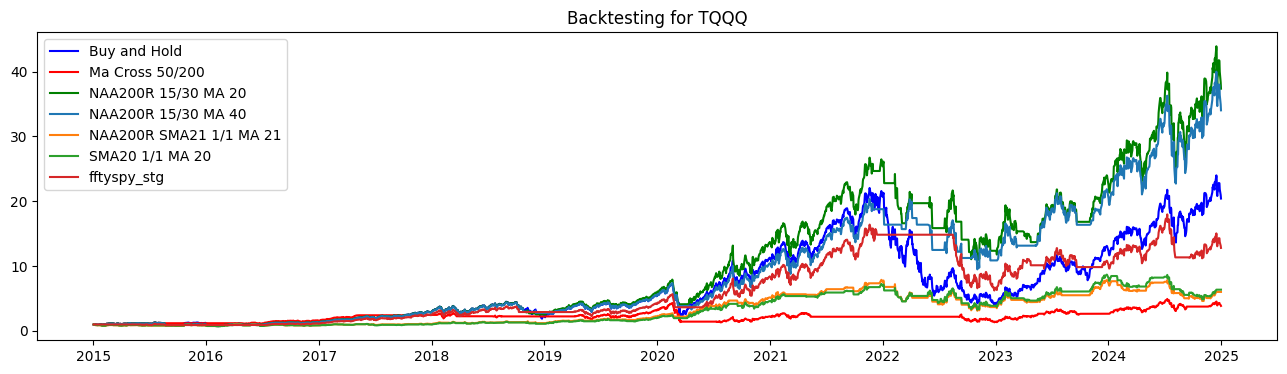

,name,num_trades,cumulative_return,annual_return,max_drawdown,sharp_ratio,avg_daily_return,std_daily_return,num_trading_days,batting Average,Gain Average,Loss Average,Risk Reward Ratio,Gain STD,Loss STD
0,Buy and Hold,2,19.413810,0.352049,-0.810158,0.050167,0.002040,0.040668,3651,1.000000,19.413810,NaN,0.000000,NaN,NaN
0,Ma Cross 50/200,12,2.861813,0.144667,-0.694114,0.033390,0.000978,0.029293,3651,0.636364,0.347026,-0.114223,3.038156,0.354713,0.167524
0,NAA200R 15/30 MA 20,24,36.354802,0.436265,-0.596052,0.060497,0.001985,0.032809,3651,0.434783,1.036309,-0.108640,9.538901,1.619086,0.052932
0,NAA200R 15/30 MA 40,23,33.017307,0.422886,-0.553646,0.060373,0.001910,0.031629,3651,0.454545,0.849728,-0.078104,10.879406,1.306041,0.066506
0,NAA200R SMA21 1/1 MA 21,133,5.016925,0.196568,-0.606457,0.041753,0.001003,0.024034,3651,0.492424,0.095470,-0.054276,1.758969,0.115894,0.046320
0,SMA20 1/1 MA 20,140,5.362112,0.203262,-0.548669,0.042670,0.001026,0.024039,3651,0.474820,0.097978,-0.052079,1.881342,0.117294,0.046631


In [106]:
perf_summary = backtestAll(tqqq, naa200r, test_start, test_end, verbose = False)
display(perf_summary)


Backtest for QQQ

Buy and Hold:
cumulative return      : 436.64%
compound anual return  : 18.2955%
max_drawdown           : -35.12%
sharp_ratio            : 5.55%
average of daily return: 0.0763%
std of daily return    : 1.3745%
number of trades       : 2,
trading days           : 3651,
batting Average        : 100.00%
Gain Average           : 436.64%
Loss Average           : nan%
Risk Reward Ratio      : 0.00
Gain STD               : nan%
Loss STD               : nan%
            

Ma Cross 50/200:
cumulative return      : 336.13%
compound anual return  : 15.8676%
max_drawdown           : -28.56%
sharp_ratio            : 5.59%
average of daily return: 0.0655%
std of daily return    : 1.1717%
number of trades       : 7,
trading days           : 3651,
batting Average        : 66.67%
Gain Average           : 53.00%
Loss Average           : -8.59%
Risk Reward Ratio      : 6.17
Gain STD               : 25.76%
Loss STD               : 6.95%
            

NAA200R 15/30 MA 20:
cumulative retu

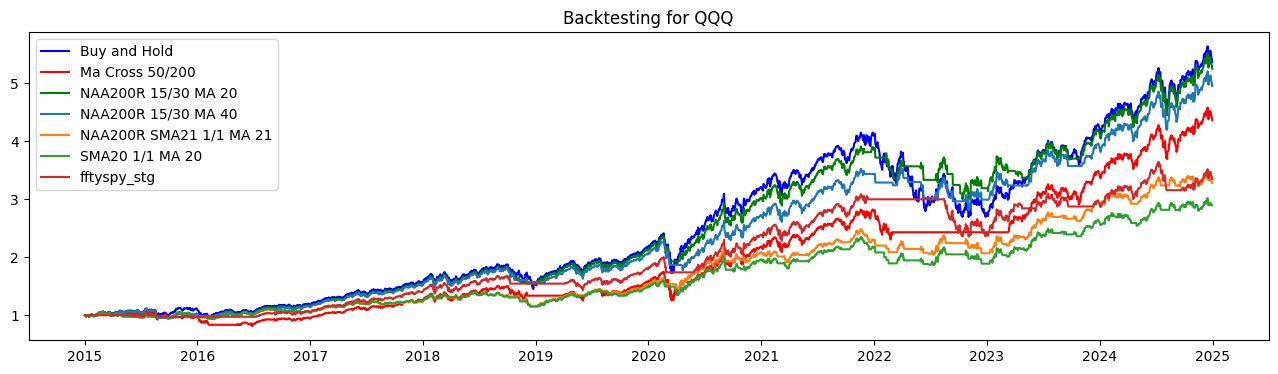

,name,num_trades,cumulative_return,annual_return,max_drawdown,sharp_ratio,avg_daily_return,std_daily_return,num_trading_days,batting Average,Gain Average,Loss Average,Risk Reward Ratio,Gain STD,Loss STD
0,Buy and Hold,2,4.366392,0.182955,-0.351187,0.055514,0.000763,0.013745,3651,1.000000,4.366392,NaN,0.000000,NaN,NaN
0,Ma Cross 50/200,7,3.361334,0.158676,-0.285594,0.055878,0.000655,0.011717,3651,0.666667,0.530010,-0.085882,6.171367,0.257566,0.069457
0,NAA200R 15/30 MA 20,24,4.252280,0.180415,-0.232338,0.065223,0.000721,0.011054,3651,0.434783,0.269270,-0.034941,7.706330,0.328815,0.016996
0,NAA200R 15/30 MA 40,23,3.953147,0.173514,-0.222638,0.065060,0.000693,0.010657,3651,0.545455,0.196072,-0.028204,6.951956,0.281538,0.022964
0,NAA200R SMA21 1/1 MA 21,119,2.285074,0.126301,-0.180616,0.060432,0.000508,0.008414,3651,0.415254,0.048103,-0.015365,3.130768,0.043608,0.011193
0,SMA20 1/1 MA 20,129,1.896002,0.112192,-0.208996,0.054095,0.000459,0.008484,3651,0.398438,0.045552,-0.015044,3.027918,0.040432,0.011640


In [107]:

perf_summary = backtestAll(qqq, qqq, test_start, test_end, verbose = False, weekly_buy=True, weekly_sell=True)
display(perf_summary)


Backtest for QLD

Buy and Hold:
cumulative return      : 1190.29%
compound anual return  : 29.1424%
max_drawdown           : -63.08%
sharp_ratio            : 5.09%
average of daily return: 0.1398%
std of daily return    : 2.7485%
number of trades       : 2,
trading days           : 3651,
batting Average        : 100.00%
Gain Average           : 1190.29%
Loss Average           : nan%
Risk Reward Ratio      : 0.00
Gain STD               : nan%
Loss STD               : nan%
            

Ma Cross 50/200:
cumulative return      : 938.52%
compound anual return  : 26.3693%
max_drawdown           : -51.72%
sharp_ratio            : 5.16%
average of daily return: 0.1208%
std of daily return    : 2.3405%
number of trades       : 7,
trading days           : 3651,
batting Average        : 66.67%
Gain Average           : 107.65%
Loss Average           : -18.10%
Risk Reward Ratio      : 5.95
Gain STD               : 63.97%
Loss STD               : 11.76%
            

NAA200R 15/30 MA 20:
cumulative

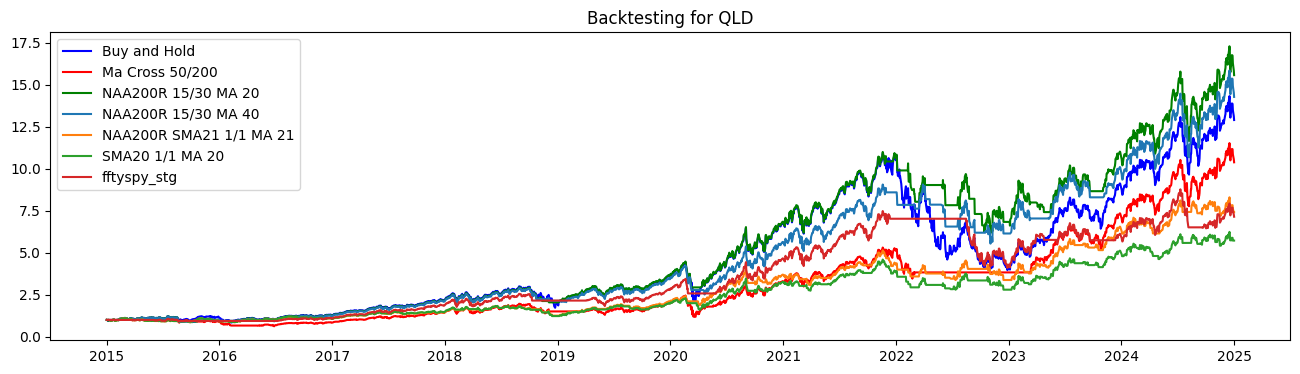

,name,num_trades,cumulative_return,annual_return,max_drawdown,sharp_ratio,avg_daily_return,std_daily_return,num_trading_days,batting Average,Gain Average,Loss Average,Risk Reward Ratio,Gain STD,Loss STD
0,Buy and Hold,2,11.902886,0.291424,-0.630810,0.050880,0.001398,0.027485,3651,1.000000,11.902886,NaN,0.000000,NaN,NaN
0,Ma Cross 50/200,7,9.385192,0.263693,-0.517154,0.051619,0.001208,0.023405,3651,0.666667,1.076534,-0.180979,5.948398,0.639671,0.117635
0,NAA200R 15/30 MA 20,24,14.575512,0.315965,-0.439677,0.060630,0.001337,0.022053,3651,0.434783,0.594809,-0.072124,8.247064,0.835992,0.034864
0,NAA200R 15/30 MA 40,23,13.278819,0.304576,-0.407344,0.060463,0.001285,0.021257,3651,0.454545,0.503110,-0.050109,10.040270,0.710089,0.046007
0,NAA200R SMA21 1/1 MA 21,119,6.409269,0.221736,-0.343567,0.055801,0.000939,0.016824,3651,0.389831,0.099732,-0.030326,3.288605,0.088188,0.022426
0,SMA20 1/1 MA 20,129,4.724100,0.190613,-0.390650,0.049417,0.000839,0.016973,3651,0.367188,0.095969,-0.029443,3.259428,0.081715,0.023448


In [108]:
perf_summary = backtestAll(qld, qqq, test_start, test_end, verbose = False, weekly_buy=True, weekly_sell=False)
display(perf_summary)

Backtest for TQQQ

Buy and Hold:
cumulative return      : 1941.38%
compound anual return  : 35.2049%
max_drawdown           : -81.02%
sharp_ratio            : 5.02%
average of daily return: 0.2040%
std of daily return    : 4.0668%
number of trades       : 2,
trading days           : 3651,
batting Average        : 100.00%
Gain Average           : 1941.38%
Loss Average           : nan%
Risk Reward Ratio      : 0.00
Gain STD               : nan%
Loss STD               : nan%
            

Ma Cross 50/200:
cumulative return      : 1730.11%
compound anual return  : 33.7358%
max_drawdown           : -69.92%
sharp_ratio            : 5.11%
average of daily return: 0.1768%
std of daily return    : 3.4612%
number of trades       : 7,
trading days           : 3651,
batting Average        : 66.67%
Gain Average           : 170.09%
Loss Average           : -27.46%
Risk Reward Ratio      : 6.19
Gain STD               : 118.76%
Loss STD               : 15.00%
            

NAA200R 15/30 MA 20:
cumulat

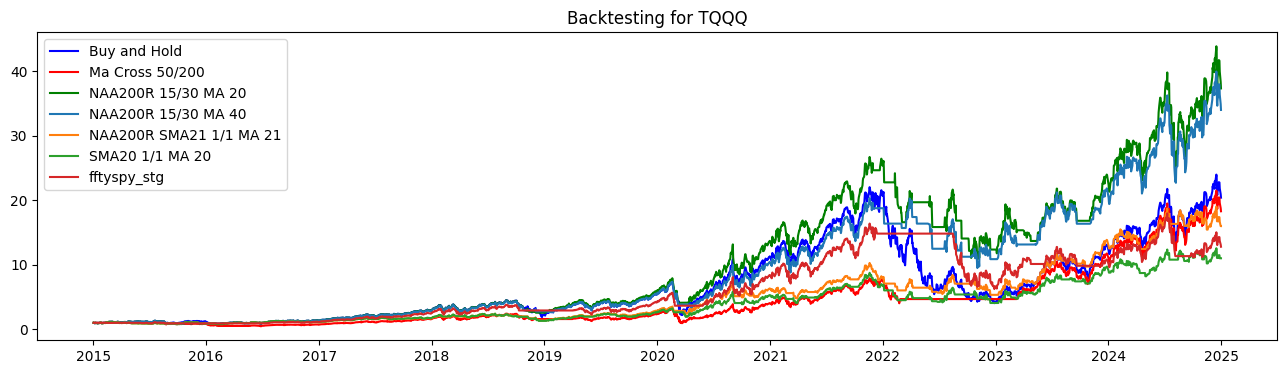

,name,num_trades,cumulative_return,annual_return,max_drawdown,sharp_ratio,avg_daily_return,std_daily_return,num_trading_days,batting Average,Gain Average,Loss Average,Risk Reward Ratio,Gain STD,Loss STD
0,Buy and Hold,2,19.413810,0.352049,-0.810158,0.050167,0.002040,0.040668,3651,1.000000,19.413810,NaN,0.000000,NaN,NaN
0,Ma Cross 50/200,7,17.301070,0.337358,-0.699221,0.051081,0.001768,0.034612,3651,0.666667,1.700868,-0.274622,6.193483,1.187573,0.150041
0,NAA200R 15/30 MA 20,24,36.354802,0.436265,-0.596052,0.060497,0.001985,0.032809,3651,0.434783,1.036309,-0.108640,9.538901,1.619086,0.052932
0,NAA200R 15/30 MA 40,23,33.017307,0.422886,-0.553646,0.060373,0.001910,0.031629,3651,0.454545,0.849728,-0.078104,10.879406,1.306041,0.066506
0,NAA200R SMA21 1/1 MA 21,118,14.999211,0.319501,-0.468530,0.056707,0.001418,0.025008,3651,0.398305,0.147723,-0.046265,3.193007,0.138393,0.032704
0,SMA20 1/1 MA 20,128,10.009416,0.271090,-0.523623,0.050558,0.001275,0.025221,3651,0.375000,0.141895,-0.044657,3.177468,0.128438,0.034182


In [109]:
perf_summary = backtestAll(tqqq, qqq, test_start, test_end, verbose = False, weekly_buy = True, weekly_sell = False)
display(perf_summary)

Backtest for TQQQ

Buy and Hold:
cumulative return      : 1941.38%
compound anual return  : 35.2049%
max_drawdown           : -81.02%
sharp_ratio            : 5.02%
average of daily return: 0.2040%
std of daily return    : 4.0668%
number of trades       : 2,
trading days           : 3651,
batting Average        : 100.00%
Gain Average           : 1941.38%
Loss Average           : nan%
Risk Reward Ratio      : 0.00
Gain STD               : nan%
Loss STD               : nan%
            

Ma Cross 50/200:
cumulative return      : 1730.11%
compound anual return  : 33.7358%
max_drawdown           : -69.92%
sharp_ratio            : 5.11%
average of daily return: 0.1768%
std of daily return    : 3.4612%
number of trades       : 7,
trading days           : 3651,
batting Average        : 66.67%
Gain Average           : 170.09%
Loss Average           : -27.46%
Risk Reward Ratio      : 6.19
Gain STD               : 118.76%
Loss STD               : 15.00%
            

NAA200R 15/30 MA 20:
cumulat

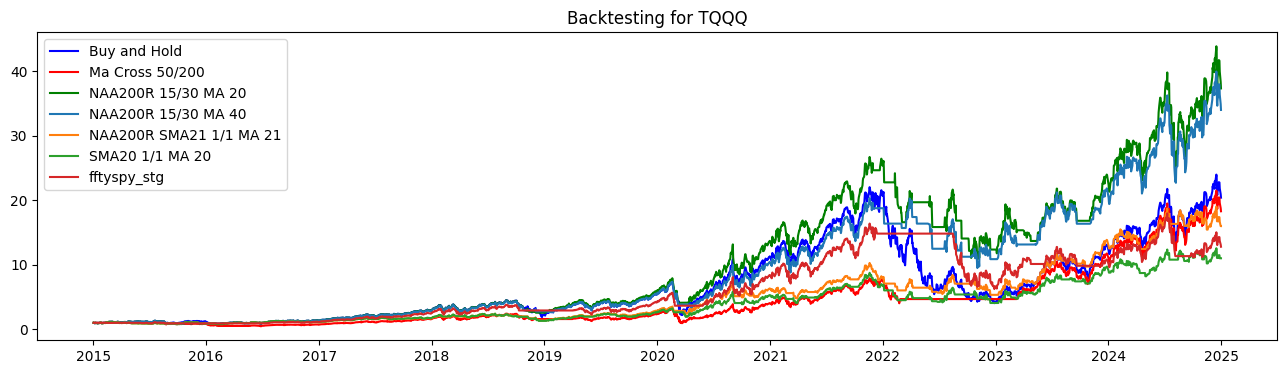

,name,num_trades,cumulative_return,annual_return,max_drawdown,sharp_ratio,avg_daily_return,std_daily_return,num_trading_days,batting Average,Gain Average,Loss Average,Risk Reward Ratio,Gain STD,Loss STD
0,Buy and Hold,2,19.413810,0.352049,-0.810158,0.050167,0.002040,0.040668,3651,1.000000,19.413810,NaN,0.000000,NaN,NaN
0,Ma Cross 50/200,7,17.301070,0.337358,-0.699221,0.051081,0.001768,0.034612,3651,0.666667,1.700868,-0.274622,6.193483,1.187573,0.150041
0,NAA200R 15/30 MA 20,24,36.354802,0.436265,-0.596052,0.060497,0.001985,0.032809,3651,0.434783,1.036309,-0.108640,9.538901,1.619086,0.052932
0,NAA200R 15/30 MA 40,23,33.017307,0.422886,-0.553646,0.060373,0.001910,0.031629,3651,0.454545,0.849728,-0.078104,10.879406,1.306041,0.066506
0,NAA200R SMA21 1/1 MA 21,118,14.999211,0.319501,-0.468530,0.056707,0.001418,0.025008,3651,0.398305,0.147723,-0.046265,3.193007,0.138393,0.032704
0,SMA20 1/1 MA 20,128,10.009416,0.271090,-0.523623,0.050558,0.001275,0.025221,3651,0.375000,0.141895,-0.044657,3.177468,0.128438,0.034182


In [110]:
perf_summary = backtestAll(tqqq, qqq, test_start, test_end, verbose = False, weekly_buy = False, weekly_sell = False)
display(perf_summary)